# Question 15
### How many distinct countries are represented in the dataset?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

IN_DIR = "cleaned_data"
home = pd.read_parquet(f"{IN_DIR}/home_team.parquet")
away = pd.read_parquet(f"{IN_DIR}/away_team.parquet")
players_unique = pd.concat([home, away], ignore_index=True).drop_duplicates(subset="player_id")

In [2]:
missing_country = players_unique["country"].isna().sum()
n_countries = players_unique["country"].nunique()

print(f"Players with no recorded country: {missing_country} "
      f"({missing_country / len(players_unique) * 100:.1f}%)")
print(f"\nAnswer to Question 15:")
print(f"Distinct countries represented: {n_countries}")

Players with no recorded country: 1 (0.0%)

Answer to Question 15:
Distinct countries represented: 100



#### =======================================================================
#### Chart -- top 15 countries by number of players
#### =======================================================================


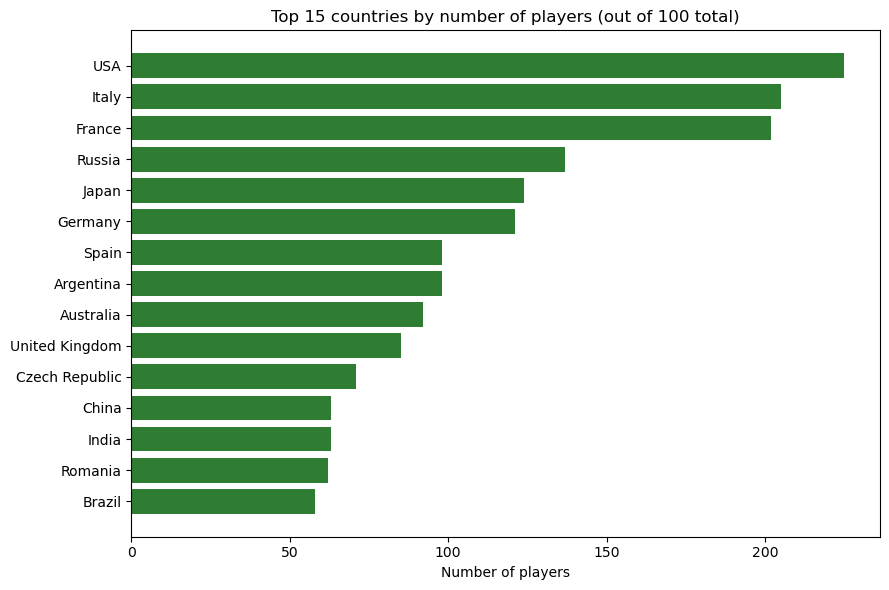

In [3]:
country_counts = players_unique["country"].value_counts()
top15 = country_counts.head(15)

plt.figure(figsize=(9, 6))
plt.barh(top15.index[::-1], top15.values[::-1], color="#2e7d32")
plt.title(f"Top 15 countries by number of players (out of {n_countries} total)")
plt.xlabel("Number of players")
plt.tight_layout()
plt.savefig('charts/q15_Top 15 countries by number of players.png', dpi=200)
plt.show()

#### =======================================================================
#### Full list of ALL countries (not just the top 15 shown in the chart)
#### Goal: the chart above is for a quick visual read; this full table is for completeness/appendix purposes, e.g. to paste into a report.
#### =======================================================================

In [4]:
all_countries = country_counts.sort_values(ascending=False).reset_index()
all_countries.columns = ["country", "n_players"]
all_countries["pct_of_players_with_country"] = (
    all_countries["n_players"] / all_countries["n_players"].sum() * 100
).round(2)

print(f"Full list of all {len(all_countries)} countries, sorted by player count:")
print(all_countries.to_string(index=False))

Full list of all 100 countries, sorted by player count:
             country  n_players  pct_of_players_with_country
                 USA        225                         8.51
               Italy        205                         7.76
              France        202                         7.64
              Russia        137                         5.18
               Japan        124                         4.69
             Germany        121                         4.58
               Spain         98                         3.71
           Argentina         98                         3.71
           Australia         92                         3.48
      United Kingdom         85                         3.22
      Czech Republic         71                         2.69
               India         63                         2.38
               China         63                         2.38
             Romania         62                         2.35
              Brazil         

#### Optional:
These two lines save the report as a separate CSV file for easier use; if you do not want this file created, do not run the cell below.

In [5]:
all_countries.to_csv("charts/question15_all_countries.csv", index=False)
print("\nSaved full country list to question15_all_countries.csv")


Saved full country list to question15_all_countries.csv
